## Food Image Classification with LIME Explanations
Train a CNN to classify food images and use LIME to explain predictions.


In [ ]:
import os
import random
from PIL import Image
from pathlib import Path

import torch
from torchvision.datasets import Food101
from torch.utils.data import DataLoader, random_split, Subset

from lime_cnn_utils import (
    get_data_transforms,
    create_cnn_model,
    train_model,
    evaluate_model,
    explain_prediction,
    visualize_explanation,
    save_model,
    load_model
)

/opt/homebrew/Caskroom/miniconda/base/envs/lime/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# config

DATA_ROOT = Path("data").resolve()
MODEL_DIR = Path("models").resolve()
OUTPUT_DIR = Path("output").resolve()

TENSORBOARD_LOG_DIR = Path("runs").resolve()
TENSORBOARD_LOG_DIR.mkdir(exist_ok=True)

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# training params
BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 0.001
TRAIN_SUBSET_SIZE = 5000
TEST_SUBSET_SIZE = 1000

# model parameters
ARCHITECTURE = "resnet18"  # choose from 'resnet18', 'resnet50', 'efficientnet'
NUM_CLASSES = 101

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# Load dataset

train_transform, val_transform = get_data_transforms()

print("Loading training dataset...")
train_dataset_full = Food101(
    root=DATA_ROOT,
    split='train',
    transform=train_transform,
    download=True
)

print("Loading test dataset...")
test_dataset_full = Food101(
    root=DATA_ROOT,
    split='test',
    transform=val_transform,
    download=True
)

# create subsets

if TRAIN_SUBSET_SIZE < len(train_dataset_full):
    train_indices = list(range(TRAIN_SUBSET_SIZE))
    train_dataset = Subset(train_dataset_full, train_indices)
else:
    train_dataset = train_dataset_full

if TEST_SUBSET_SIZE < len(test_dataset_full):
    test_indices = list(range(TEST_SUBSET_SIZE))
    test_dataset = Subset(test_dataset_full, test_indices)
else:
    test_dataset = test_dataset_full

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of classes: {len(train_dataset_full.classes)}")

class_names = train_dataset_full.classes
print(f"Sample classes: {class_names[:5]}")

Loading training dataset...
Loading test dataset...
Training samples: 5000
Test samples: 1000
Number of classes: 101
Sample classes: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare']


### 3 Data Loading


In [ ]:
train_transform, val_transform = get_data_transforms()

print("Loading training dataset...")
train_dataset_full = Food101(
    root=DATA_ROOT,
    split='train',
    transform=train_transform,
    download=True
)

print("Loading test dataset...")
test_dataset_full = Food101(
    root=DATA_ROOT,
    split='test',
    transform=val_transform,
    download=True
)

# use a subset of the entire dataset

if TRAIN_SUBSET_SIZE < len(train_dataset_full):
    train_indices = list(range(TRAIN_SUBSET_SIZE))
    train_dataset = Subset(train_dataset_full, train_indices)
else:
    train_dataset = train_dataset_full

if TEST_SUBSET_SIZE < len(test_dataset_full):
    test_indices = list(range(TEST_SUBSET_SIZE))
    test_dataset = Subset(test_dataset_full, test_indices)
else:
    test_dataset = test_dataset_full

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of classes: {len(train_dataset_full.classes)}")

class_names = train_dataset_full.classes
print(f"Sample classes: {class_names[:5]}")

Loading training dataset...
Loading test dataset...
Training samples: 5000
Test samples: 1000
Number of classes: 101
Sample classes: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare']


In [6]:
# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 157
Test batches: 32


### 4 Model Creation


In [7]:
# Create model
model = create_cnn_model(
    num_classes=NUM_CLASSES,
    architecture=ARCHITECTURE,
    pretrained=True
)

print(f"Model architecture: {ARCHITECTURE}")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Model architecture: resnet18
Number of parameters: 11,228,325
Trainable parameters: 11,228,325


/opt/homebrew/Caskroom/miniconda/base/envs/lime/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/lime/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### 5 Model Training

In [ ]:
# split training data for validation

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

train_loader_subset = DataLoader(
    train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)
val_loader = DataLoader(
    val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)

print(f"Training subset: {len(train_subset)} samples")
print(f"Validation subset: {len(val_subset)} samples")


Training subset: 4000 samples
Validation subset: 1000 samples


In [ ]:
# train model
print("Starting training...")
history = train_model(
    model=model,
    train_loader=train_loader_subset,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    device=device,
    learning_rate=LEARNING_RATE,
    log_dir=str(TENSORBOARD_LOG_DIR)
)

print("Training completed!")


Starting training...
TensorBoard logging enabled. Logs saved to: /Users/damith/lime/runs/run_20251110_164404
View logs with: tensorboard --logdir=/Users/damith/lime/runs/run_20251110_164404
Epoch [1/10]
Train Loss: 0.9577, Train Acc: 69.25%
Val Loss: 1.3289, Val Acc: 57.70%
--------------------------------------------------
Epoch [2/10]
Train Loss: 0.6321, Train Acc: 78.42%
Val Loss: 0.6741, Val Acc: 76.10%
--------------------------------------------------
Epoch [3/10]
Train Loss: 0.5596, Train Acc: 81.55%
Val Loss: 0.6520, Val Acc: 78.80%
--------------------------------------------------
Epoch [4/10]
Train Loss: 0.4776, Train Acc: 84.00%
Val Loss: 0.5299, Val Acc: 82.50%
--------------------------------------------------
Epoch [5/10]
Train Loss: 0.4035, Train Acc: 86.80%
Val Loss: 0.7592, Val Acc: 78.10%
--------------------------------------------------
Epoch [6/10]
Train Loss: 0.3717, Train Acc: 87.22%
Val Loss: 0.8538, Val Acc: 73.80%
---------------------------------------------

#### View Training in TensorBoard

To view the training metrics in TensorBoard, run the following command in your terminal and navigate to the provided link in your browser.

```bash
tensorboard --logdir=runs
```

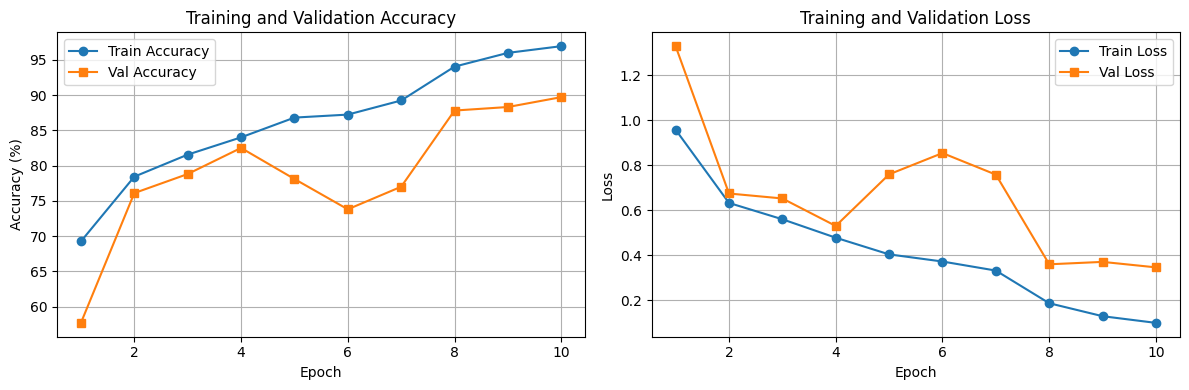

In [ ]:
# plot training history

epochs = [h['epoch'] for h in history]
train_acc = [h['train_acc'] for h in history]
val_acc = [h['val_acc'] for h in history]
train_loss = [h['train_loss'] for h in history]
val_loss = [h['val_loss'] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_acc, label='Train Accuracy', marker='o')
axes[0].plot(epochs, val_acc, label='Val Accuracy', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Training and Validation Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, train_loss, label='Train Loss', marker='o')
axes[1].plot(epochs, val_loss, label='Val Loss', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training and Validation Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'training_history.png'), dpi=150)
plt.show()

### 6 Model Evaluation

In [ ]:
# eval on test set
print("Evaluating on test set...")
results = evaluate_model(model, test_loader, device=device)

print(f"\nTest Results:")
print(f"Accuracy: {results['accuracy']:.2f}%")
print(f"Correct: {results['correct']}/{results['total']}")

### 7 Save Model

In [ ]:
# save model
model_path = os.path.join(MODEL_DIR, f"food_classifier_{ARCHITECTURE}.pth")
save_model(model, model_path, train_dataset_full.class_to_idx)
print(f"Model saved to {model_path}")